<a href="https://colab.research.google.com/github/Santhosh261005/Deep-Learning/blob/main/DL_LAB_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**W2-1) Implement AND and OR logic operations using a single perceptron, and verify the correctness of the output using appropriate truth tables. (linear Data)**

In [ ]:
def andOp(x1,x2):
  if(x1+x2 == 2):
    return 1
  else:
    return 0

def orOp(x1,x2):
  if(x1+x2 >= 1):
    return 1
  else:
    return 0

print(andOp(1,1))
print(orOp(0,0))


1
0


**2) Examine the feasibility of implementing the XOR and XNOR (¬XOR) operations (Non linear data) using a single perceptron. If not possible, clearly explain the reason based on the concept of linear separability.**

Not Possible because a single perceptron can take only one decision at a time...

**3) Implement the XOR and (¬XOR) logic operation using a multi-perceptron network, and analyze how multiple perceptrons overcome the limitations of a single perceptron.**

In [ ]:
def XOR(x1,x2):
  val1 = orOp(x1,x2)
  val2 = andOp(x1,x2)
  # Corrected: Use 1 - val2 for logical NOT on binary values
  val2 = 1 - val2
  return andOp(val1,val2)

print(XOR(0,0))

0


In [ ]:
def XNOR(x1,x2):
  val1 = andOp(x1,x2)
  val2 = orOp(x1,x2)
  val2 = 1-val2
  return orOp(val1,val2)

print(XNOR(0,0))

1


**4) Demonstrate that the thresholding logic used by perceptron is very harsh.**

In [ ]:
def eval(x):
  if(x>0.5):
    return 1
  return 0

print(eval(0.49))
print(eval(0.51)) ## Therefore it is harsh

0
1


**5) Implement the Perceptron Learning Algorithm and study the effect of weight updates on convergence for a binary decision problem such as determining whether a user would like to watch a movie.**

In [1]:
import numpy as np

class Perceptron:
    def __init__(self, lr=1, epochs=10):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        for epoch in range(self.epochs):
            print("\nEpoch", epoch + 1)

            for i in range(len(X)):
                x_i = X[i]
                y_pred = self.predict(x_i)

                error = y[i] - y_pred

                if error != 0:
                    self.w = self.w + self.lr * error * x_i
                    self.b = self.b + self.lr * error

                print("Input:", x_i, "Pred:", y_pred)
                print("Weights:", self.w, "Bias:", self.b)

    def predict(self, x):
        if np.dot(self.w, x) + self.b >= 0:
            return 1
        else:
            return 0


# Dataset (Movie preference)
X = np.array([
    [1, 0, 1],
    [1, 1, 0],
    [0, 1, 1],
    [0, 0, 0]
])

y = np.array([1, 1, 1, 0])

model = Perceptron(lr=1, epochs=5)
model.fit(X, y)

print("\nFinal Predictions:")
for x in X:
    print(x, "->", model.predict(x))


Epoch 1
Input: [1 0 1] Pred: 1
Weights: [0. 0. 0.] Bias: 0
Input: [1 1 0] Pred: 1
Weights: [0. 0. 0.] Bias: 0
Input: [0 1 1] Pred: 1
Weights: [0. 0. 0.] Bias: 0
Input: [0 0 0] Pred: 1
Weights: [0. 0. 0.] Bias: -1

Epoch 2
Input: [1 0 1] Pred: 0
Weights: [1. 0. 1.] Bias: 0
Input: [1 1 0] Pred: 1
Weights: [1. 0. 1.] Bias: 0
Input: [0 1 1] Pred: 1
Weights: [1. 0. 1.] Bias: 0
Input: [0 0 0] Pred: 1
Weights: [1. 0. 1.] Bias: -1

Epoch 3
Input: [1 0 1] Pred: 1
Weights: [1. 0. 1.] Bias: -1
Input: [1 1 0] Pred: 1
Weights: [1. 0. 1.] Bias: -1
Input: [0 1 1] Pred: 1
Weights: [1. 0. 1.] Bias: -1
Input: [0 0 0] Pred: 0
Weights: [1. 0. 1.] Bias: -1

Epoch 4
Input: [1 0 1] Pred: 1
Weights: [1. 0. 1.] Bias: -1
Input: [1 1 0] Pred: 1
Weights: [1. 0. 1.] Bias: -1
Input: [0 1 1] Pred: 1
Weights: [1. 0. 1.] Bias: -1
Input: [0 0 0] Pred: 0
Weights: [1. 0. 1.] Bias: -1

Epoch 5
Input: [1 0 1] Pred: 1
Weights: [1. 0. 1.] Bias: -1
Input: [1 1 0] Pred: 1
Weights: [1. 0. 1.] Bias: -1
Input: [0 1 1] Pred: 1
We

**Demonstrate the Representation Power of a Network of Perceptrons
How many Boolean functions can be designed using two binary inputs?
For each Boolean function, determine whether it is linearly separable.**
code generates all Boolean functions, trains a perceptron for each using weight updates on errors, checks convergence, and classifies functions as linearly separable or not based on whether learning is successful

In [2]:
import numpy as np
from itertools import product

# Step function
def step(x):
    if x >= 0:
        return 1
    else:
        return 0

# Perceptron training
def train_perceptron(X, y, epochs=20, lr=1):
    w = np.zeros(2)
    b = 0

    for _ in range(epochs):
        error_flag = False

        for i in range(len(X)):
            x_i = X[i]
            y_pred = step(np.dot(w, x_i) + b)

            error = y[i] - y_pred

            if error != 0:
                w = w + lr * error * x_i
                b = b + lr * error
                error_flag = True

        if not error_flag:
            return True  # converged

    return False  # did not converge


# Input combinations
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

# Generate all 16 Boolean functions
functions = list(product([0,1], repeat=4))

linearly_separable = 0
non_separable = 0

for i, f in enumerate(functions):
    y = np.array(f)

    result = train_perceptron(X, y)

    print("Function", i+1, ":", f, "->", "Learned" if result else "Not Learned")

    if result:
        linearly_separable += 1
    else:
        non_separable += 1

print("\nLinearly separable:", linearly_separable)
print("Not linearly separable:", non_separable)

Function 1 : (0, 0, 0, 0) -> Learned
Function 2 : (0, 0, 0, 1) -> Learned
Function 3 : (0, 0, 1, 0) -> Learned
Function 4 : (0, 0, 1, 1) -> Learned
Function 5 : (0, 1, 0, 0) -> Learned
Function 6 : (0, 1, 0, 1) -> Learned
Function 7 : (0, 1, 1, 0) -> Not Learned
Function 8 : (0, 1, 1, 1) -> Learned
Function 9 : (1, 0, 0, 0) -> Learned
Function 10 : (1, 0, 0, 1) -> Not Learned
Function 11 : (1, 0, 1, 0) -> Learned
Function 12 : (1, 0, 1, 1) -> Learned
Function 13 : (1, 1, 0, 0) -> Learned
Function 14 : (1, 1, 0, 1) -> Learned
Function 15 : (1, 1, 1, 0) -> Learned
Function 16 : (1, 1, 1, 1) -> Learned

Linearly separable: 14
Not linearly separable: 2


**7) Design and implement a Multi-Layer Perceptron (MLP) architecture capable of realizing all basic Boolean functions**
The code defines hidden neurons that activate for specific input combinations and uses an output neuron to combine these activations based on selected weights. By adjusting output weights, different Boolean functions can be implemented.

In [1]:
import numpy as np

def step(x):
    if x >= 0:
        return 1
    else:
        return 0

# Hidden layer (pattern detectors)
def hidden_layer(x1, x2):
    h1 = step(-x1 - x2 + 0.5)   # (0,0)
    h2 = step(-x1 + x2 - 0.5)   # (0,1)
    h3 = step(x1 - x2 - 0.5)    # (1,0)
    h4 = step(x1 + x2 - 1.5)    # (1,1)
    return [h1, h2, h3, h4]

# Output layer (customizable)
def mlp(x1, x2, weights):
    h = hidden_layer(x1, x2)

    y = 0
    for i in range(4):
        y = y + weights[i] * h[i]

    return step(y - 0.5)


# Example: XOR function
# Output = 1 for (0,1) and (1,0)
weights = [0, 1, 1, 0]

inputs = [(0,0), (0,1), (1,0), (1,1)]

print("XOR using MLP:")
for x in inputs:
    print(x, "->", mlp(x[0], x[1], weights))

XOR using MLP:
(0, 0) -> 0
(0, 1) -> 1
(1, 0) -> 1
(1, 1) -> 0


**8) How many Boolean functions can be designed using three binary inputs?**
The hidden layer checks all possible input patterns and activates only the neuron corresponding to the exact match, creating a one-hot representation. The output layer uses a weight vector to map each input combination to its desired output, enabling the implementation of any Boolean function.

In [2]:
import numpy as np

def step(x):
    if x >= 0:
        return 1
    else:
        return 0

# Hidden layer (8 neurons)
def hidden_layer(x1, x2, x3):
    h = []

    patterns = [
        (0,0,0),(0,0,1),(0,1,0),(0,1,1),
        (1,0,0),(1,0,1),(1,1,0),(1,1,1)
    ]

    for p in patterns:
        val = 0
        for i in range(3):
            if p[i] == 1:
                val += [x1, x2, x3][i]
            else:
                val += (1 - [x1, x2, x3][i])
        h.append(step(val - 3))   # fires only if exact match

    return h


# MLP output
def mlp(x1, x2, x3, weights):
    h = hidden_layer(x1, x2, x3)

    y = 0
    for i in range(8):
        y += weights[i] * h[i]

    return step(y - 0.5)


# Example: function where output=1 only for (1,1,1)
weights = [0,0,0,0,0,0,0,1]

inputs = [
    (0,0,0),(0,0,1),(0,1,0),(0,1,1),
    (1,0,0),(1,0,1),(1,1,0),(1,1,1)
]

print("Example Boolean Function:")
for x in inputs:
    print(x, "->", mlp(x[0], x[1], x[2], weights))

Example Boolean Function:
(0, 0, 0) -> 0
(0, 0, 1) -> 0
(0, 1, 0) -> 0
(0, 1, 1) -> 0
(1, 0, 0) -> 0
(1, 0, 1) -> 0
(1, 1, 0) -> 0
(1, 1, 1) -> 1


# **Week -3**

**9) Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.** An MLP is trained on the XOR dataset using different learning rates. For each learning rate, the network is trained using forward propagation and backpropagation, and the final loss is recorded. A graph is plotted between learning rate and loss to analyze the effect of learning rate on convergence. It is observed that moderate learning rates lead to better convergence, while very small or very large values degrade performance.

Learning Rate: 0.01 Final Loss: 0.24776644867258835
Learning Rate: 0.05 Final Loss: 0.2400197378194891
Learning Rate: 0.1 Final Loss: 0.2359297400809442
Learning Rate: 0.5 Final Loss: 0.25000126234988057
Learning Rate: 1.0 Final Loss: 0.0009583110045617041


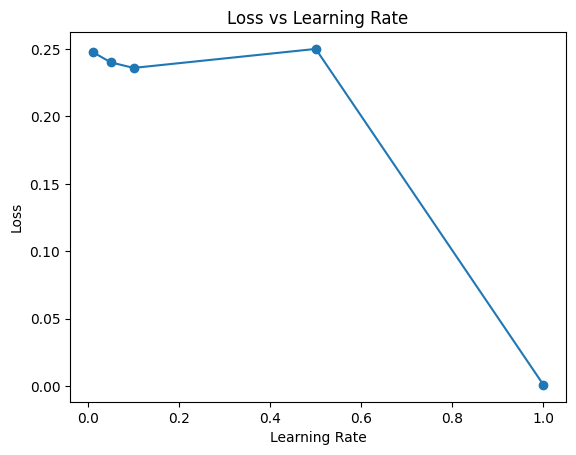

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# derivative of sigmoid
def sigmoid_derivative(x):
    return x * (1 - x)

# train function
def train_mlp(lr):
    # initialize weights and bias
    W1 = np.random.rand(2,2)
    b1 = np.zeros((1,2))
    W2 = np.random.rand(2,1)
    b2 = np.zeros((1,1))

    # training
    for epoch in range(2000):

        # forward pass
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        # loss (MSE)
        loss = np.mean((y - a2) ** 2)

        # backward pass
        d2 = (y - a2) * sigmoid_derivative(a2)
        d1 = np.dot(d2, W2.T) * sigmoid_derivative(a1)

        # update weights
        W2 = W2 + lr * np.dot(a1.T, d2)
        b2 = b2 + lr * np.sum(d2, axis=0)

        W1 = W1 + lr * np.dot(X.T, d1)
        b1 = b1 + lr * np.sum(d1, axis=0)

    return loss


# different learning rates
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
loss_values = []

# train for each learning rate
for lr in learning_rates:
    loss = train_mlp(lr)
    loss_values.append(loss)
    print("Learning Rate:", lr, "Final Loss:", loss)

# plot graph
plt.plot(learning_rates, loss_values, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.show()

**10) Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.** --> Write same answer as above for this too

**11) Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn.**

In [4]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the iris dataset
iris = load_iris()

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.3, random_state=0)

# Create a Perceptron object
perceptron = Perceptron()

# Train the Perceptron on the training data
perceptron.fit(X_train, y_train)

# Use the trained Perceptron to make predictions on the testing data
y_pred = perceptron.predict(X_test)

# Evaluate the accuracy of the Perceptron
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


**12) -didn't do...i think its not necessary**

**13) **

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (54000, 784)
Testing shape: (6000, 784)
Iteration 1, loss = 0.54125506
Iteration 2, loss = 0.26261541
Iteration 3, loss = 0.21334693
Iteration 4, loss = 0.18041799
Iteration 5, loss = 0.15521071
Iteration 6, loss = 0.13713162
Iteration 7, loss = 0.12167082


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Training set score: 0.9722777777777778
Testing set score: 0.9656666666666667
Predicted value: 6
Actual value: 6


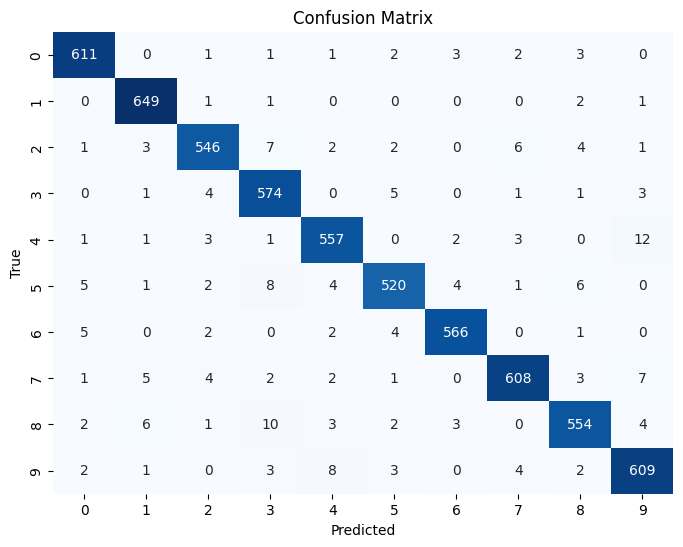

Iteration 1, loss = 0.58402398
Iteration 2, loss = 0.38397781
Iteration 3, loss = 0.39906015
Iteration 4, loss = 0.39794427
Iteration 5, loss = 0.42552618
Iteration 6, loss = 0.42483506
Iteration 7, loss = 0.43145128
Iteration 8, loss = 0.42965931
Iteration 9, loss = 0.48689868
Iteration 10, loss = 0.43131150
Iteration 11, loss = 0.44657347
Iteration 12, loss = 0.44554835
Iteration 13, loss = 0.43811670
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Training set score (MLP2): 0.8982037037037037
Testing set score (MLP2): 0.8838333333333334


In [5]:
# =========================
# Load MNIST dataset
# =========================
from tensorflow.keras.datasets import mnist

(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# =========================
# Normalize data
# =========================
X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0

# =========================
# Flatten images (28x28 -> 784)
# =========================
X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full  = X_test_full.reshape(-1, 28*28)

# =========================
# Train-validation split
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

# =========================
# Train MLP Classifier
# =========================
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1
)

mlp.fit(X_train, y_train)

# =========================
# Accuracy
# =========================
print("Training set score:", mlp.score(X_train, y_train))
print("Testing set score:", mlp.score(X_test, y_test))

# =========================
# Test single sample
# =========================
index = 346
test_digit = X_test[index].reshape(1, 784)

prediction = mlp.predict(test_digit)[0]

print("Predicted value:", prediction)
print("Actual value:", y_test[index])

# =========================
# Confusion Matrix
# =========================
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

preds = mlp.predict(X_test)

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# =========================
# MLP with higher learning rate
# =========================
mlp2 = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=50,
    verbose=1,
    random_state=1,
    learning_rate_init=0.1
)

mlp2.fit(X_train, y_train)

print("Training set score (MLP2):", mlp2.score(X_train, y_train))
print("Testing set score (MLP2):", mlp2.score(X_test, y_test))


# **Week-4**

14)